In [1]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.data.fetch_data import load_all_raw, STOCK_UNIVERSE
from src.data.preprocess import preprocess_all
from src.utils.metrics import evaluate
from src.models.transformer import (
    StockTransformer, train_transformer,
    predict_test_transformer, forecast_future_transformer,
    run_transformer_pipeline
)

plt.style.use("seaborn-v0_8-whitegrid")
print(f"PyTorch {torch.__version__}")

PyTorch 2.11.0+cu130


In [2]:
raw = load_all_raw()
processed = preprocess_all(raw, save=False)
print(f"Loaded {len(processed)} stocks")

INFO | Preprocessing HDFCBANK.NS …
INFO | Preprocessing ICICIBANK.NS …
INFO | Preprocessing TCS.NS …
INFO | Preprocessing INFY.NS …
INFO | Preprocessing SUNPHARMA.NS …
INFO | Preprocessing DRREDDY.NS …
INFO | Preprocessing HINDUNILVR.NS …
INFO | Preprocessing ITC.NS …
INFO | Preprocessing MARUTI.NS …
INFO | Preprocessing complete.


Loaded 9 stocks


INFO |     Epoch 10/30  loss=0.002690
INFO |     Epoch 20/30  loss=0.001904
INFO |     Epoch 30/30  loss=0.001901


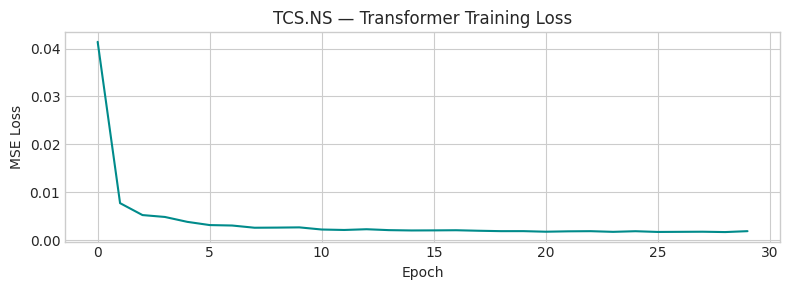

In [3]:
TICKER = "TCS.NS"
SEQ_LEN = 60
EPOCHS = 30

d = processed[TICKER]
train, test = d["train"], d["test"]
tr_sc, te_sc, scaler = d["train_scaled"], d["test_scaled"], d["scaler"]

model = StockTransformer(seq_len=SEQ_LEN)
losses = train_transformer(model, tr_sc, seq_len=SEQ_LEN, epochs=EPOCHS)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, color="darkcyan")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title(f"{TICKER} — Transformer Training Loss")
plt.tight_layout()
plt.show()

Transformer Metrics for TCS.NS:
  Ticker: TCS.NS
  Model: Transformer
  RMSE: 41.6405
  MAPE: 1.0637
  DirAcc: 49.19


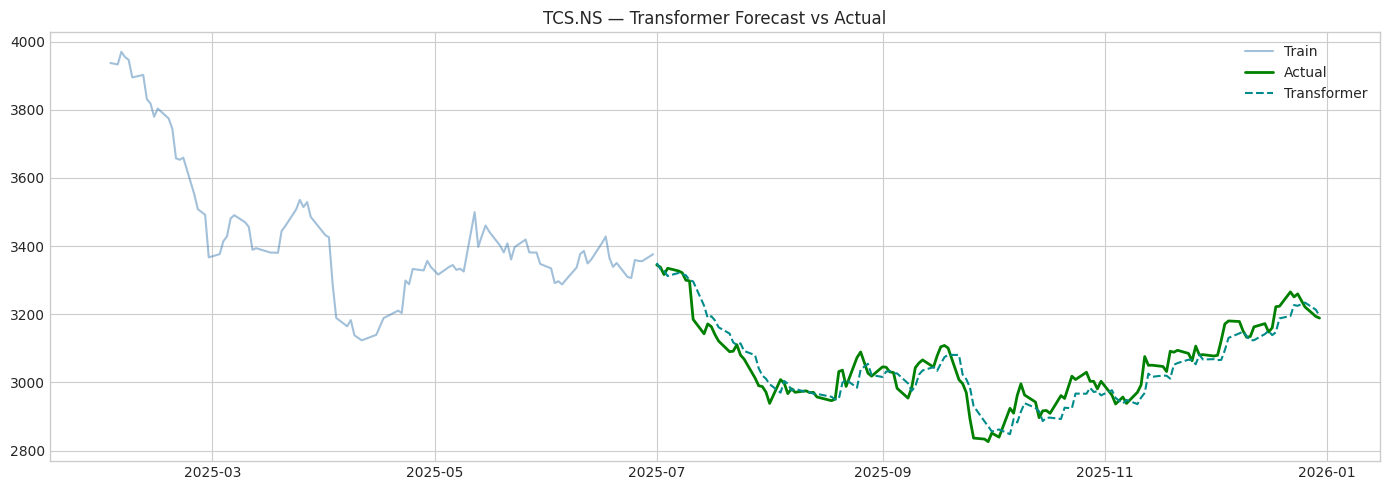

In [4]:
raw_preds = predict_test_transformer(model, tr_sc, te_sc, scaler, SEQ_LEN)
pred = pd.Series(raw_preds, index=test.index, name="Transformer_Pred")

metrics = evaluate(test.values, pred.values, "Transformer", TICKER)
print(f"Transformer Metrics for {TICKER}:")
for k, v in metrics.items():
    print(f"  {k}: {v}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train[-100:], label="Train", color="steelblue", alpha=0.5)
ax.plot(test, label="Actual", color="green", linewidth=2)
ax.plot(pred, label="Transformer", color="darkcyan", linewidth=1.5, linestyle="--")
ax.set_title(f"{TICKER} — Transformer Forecast vs Actual")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
trans_preds, trans_fc, trans_met = run_transformer_pipeline(processed, epochs=EPOCHS)

trans_df = pd.DataFrame(trans_met)
print("\n── Transformer Results ──")
print(trans_df.to_string())
print(f"\nAvg MAPE: {trans_df['MAPE'].mean():.2f}%  |  Avg DirAcc: {trans_df['DirAcc'].mean():.1f}%")

INFO | Transformer | HDFCBANK.NS
INFO |     Epoch 10/30  loss=0.002466
INFO |     Epoch 20/30  loss=0.001947
INFO |     Epoch 30/30  loss=0.001858
INFO | Transformer | ICICIBANK.NS
INFO |     Epoch 10/30  loss=0.002025
INFO |     Epoch 20/30  loss=0.001319
INFO |     Epoch 30/30  loss=0.001190
INFO | Transformer | TCS.NS
INFO |     Epoch 10/30  loss=0.002246
INFO |     Epoch 20/30  loss=0.001882
INFO |     Epoch 30/30  loss=0.001721
INFO | Transformer | INFY.NS
INFO |     Epoch 10/30  loss=0.003061
INFO |     Epoch 20/30  loss=0.002030
INFO |     Epoch 30/30  loss=0.001882
INFO | Transformer | SUNPHARMA.NS
INFO |     Epoch 10/30  loss=0.001919
INFO |     Epoch 20/30  loss=0.001196
INFO |     Epoch 30/30  loss=0.001159
INFO | Transformer | DRREDDY.NS
INFO |     Epoch 10/30  loss=0.002536
INFO |     Epoch 20/30  loss=0.001867
INFO |     Epoch 30/30  loss=0.001875
INFO | Transformer | HINDUNILVR.NS
INFO |     Epoch 10/30  loss=0.002411
INFO |     Epoch 20/30  loss=0.001695
INFO |     Epoc


── Transformer Results ──
          Ticker        Model       RMSE     MAPE  DirAcc
0    HDFCBANK.NS  Transformer    10.5310   0.8492   53.23
1   ICICIBANK.NS  Transformer    40.4625   2.6888   50.81
2         TCS.NS  Transformer    44.3552   1.1601   47.58
3        INFY.NS  Transformer    24.2687   1.2825   51.61
4   SUNPHARMA.NS  Transformer    40.7529   1.9931   50.00
5     DRREDDY.NS  Transformer    24.0247   1.4908   49.19
6  HINDUNILVR.NS  Transformer    33.5764   1.0070   46.77
7         ITC.NS  Transformer     5.0777   1.0925   50.81
8      MARUTI.NS  Transformer  1932.0338  10.4999   50.81

Avg MAPE: 2.45%  |  Avg DirAcc: 50.1%


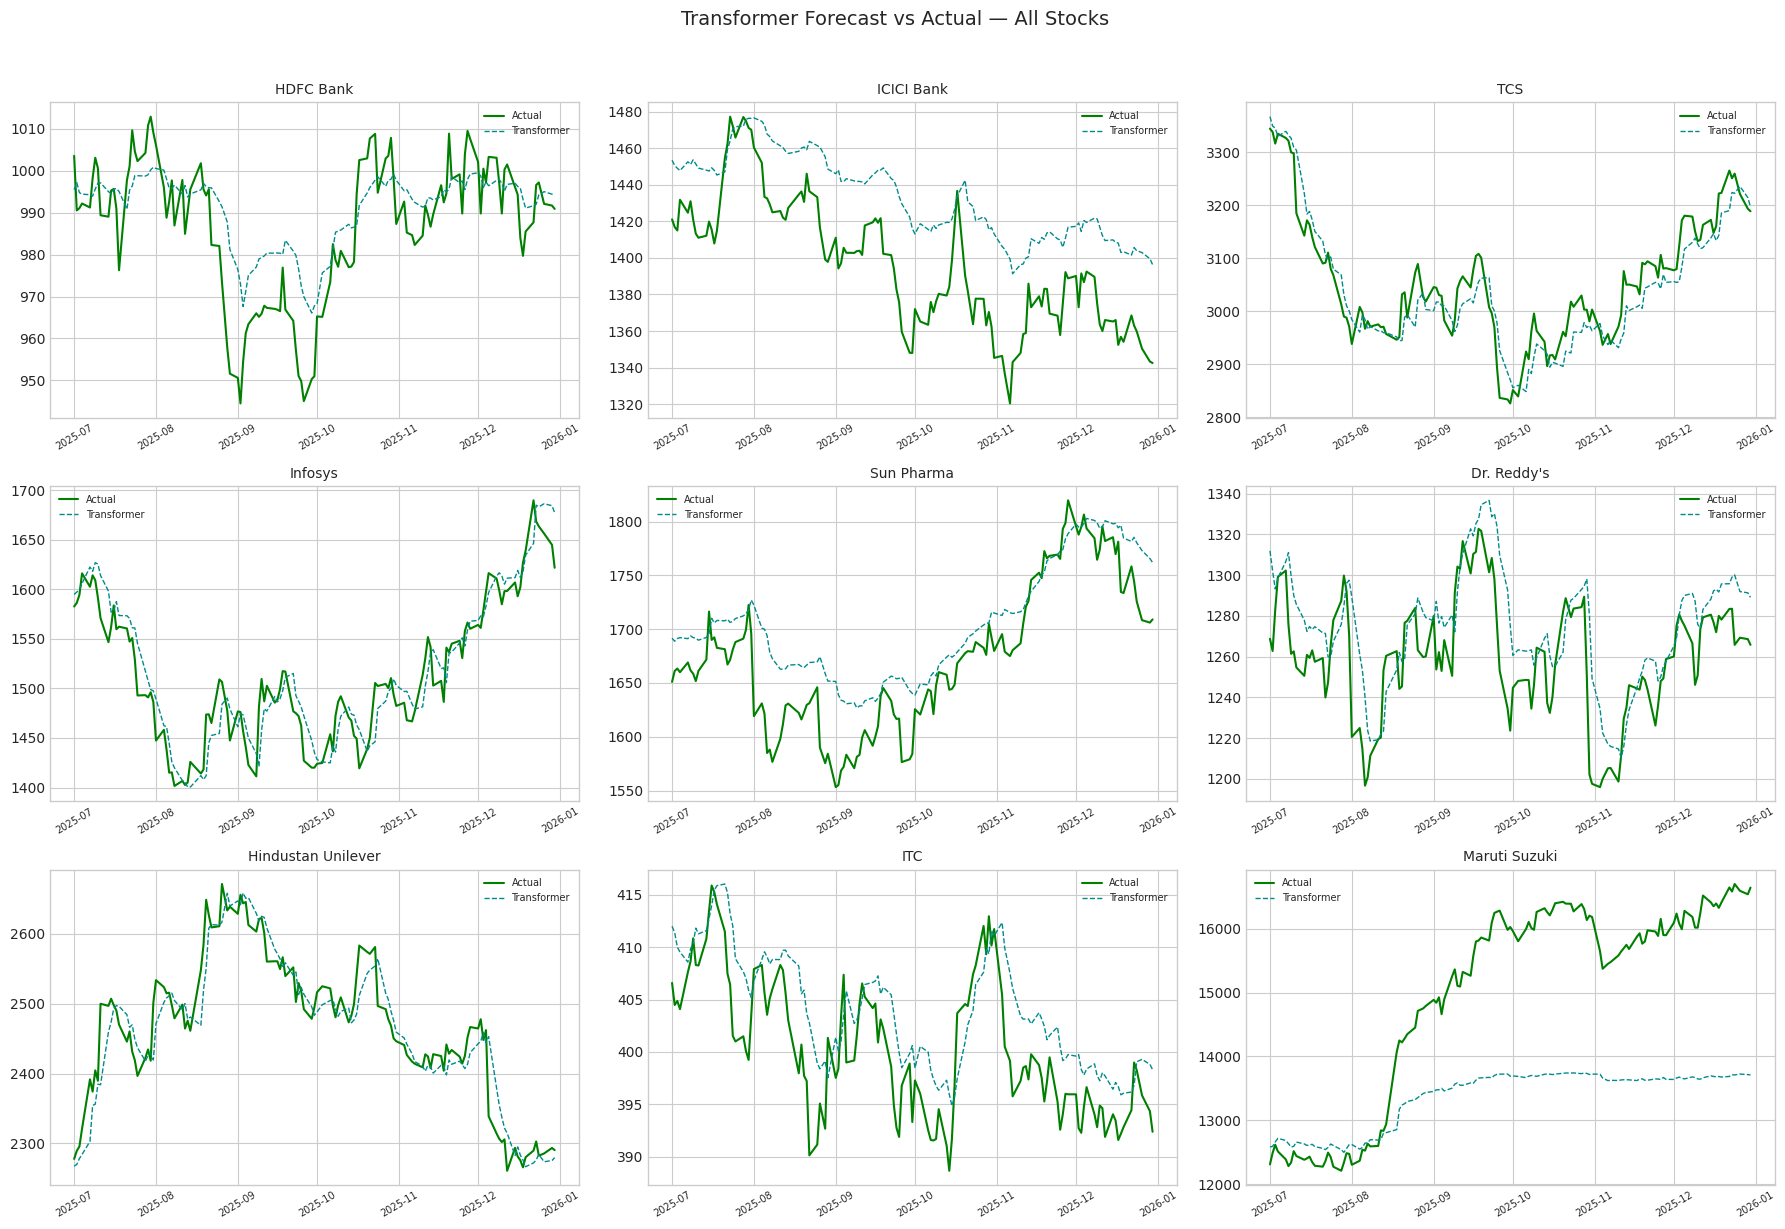

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for i, (ticker, pred) in enumerate(trans_preds.items()):
    if i >= 9: break
    ax = axes[i]
    actual = processed[ticker]["test"]
    ax.plot(actual, label="Actual", color="green", linewidth=1.5)
    ax.plot(pred, label="Transformer", color="darkcyan", linewidth=1, linestyle="--")
    ax.set_title(STOCK_UNIVERSE.get(ticker, ticker), fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.legend(fontsize=7)
plt.suptitle("Transformer Forecast vs Actual — All Stocks", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()